<a href="https://colab.research.google.com/github/raisharad/GenerativeAIandAgenticAI/blob/main/Classification_Models_Exercise_Sharad_Kumar_Rai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification Models: From Binary Diagnosis to Multiclass Prediction

---

> ### 📋 Practice Exercise. Not Graded.
> This is a **practice assignment** for self-assessment. The marks shown throughout are **indicative only**. They tell you where to spend your effort and where you might need more practice. **None of these marks count towards your final grade.**
>
> Attempt every section. Compare your results. Revisit what trips you up.

---

## What You Will Build

Two classifiers, two datasets, one progression from simple to complex.

| Part | Dataset | Task | Primary Metric |
|------|---------|------|----------------|
| **Part 1** | Breast Cancer (sklearn) | Binary: Malignant vs Benign | Recall (Sensitivity) |
| **Part 2** | Wine (sklearn) | Multiclass: 3 wine cultivars | Macro-averaged F1-Score |

**Indicative Marks: 100** (Part 1: 55 | Part 2: 45)

### Before You Start
- Complete all cells marked with `# TODO`.
- Markdown cells marked **[Your Answer]** need written responses. Don't skip them.
- Run `Runtime > Restart and run all` before reviewing. The notebook should execute top to bottom without errors.
- Use `random_state=42` wherever a function accepts it. This keeps your results reproducible.


---
# PART 1: Binary Classification, Breast Cancer Prediction

## Context

Early detection of malignant tumours saves lives. In this part, you will build classifiers that predict whether a breast tumour is **malignant** or **benign** based on features computed from cell nuclei images.

**Why Recall matters here:** A false negative means telling a patient their tumour is benign when it is actually malignant. That is a missed cancer diagnosis. A false positive means an unnecessary follow-up test. Annoying, but survivable. The asymmetry is stark: we prioritise **recall for the malignant class** above everything else.

> **Clinical Constraint:** We want recall ≥ 0.95 for malignant cases, while keeping precision ≥ 0.60 (i.e., not flooding clinics with false alarms).


## Stage 1: Data and Package Loading

<font color="red">**[3 marks]**</font>

Load the Breast Cancer Wisconsin dataset from `sklearn.datasets`.

**What to do:**
- The libraries below are pre-imported. Review them, add anything else you need.
- Load the dataset using `load_breast_cancer()`
- Convert it to a DataFrame with proper column names
- Separate features (`X`) and target (`y`)

> **Watch out:** In the raw dataset, `0 = malignant` and `1 = benign`. Since `recall_score` defaults to `pos_label=1`, we need malignant to be 1. **Remap the target** with `y = 1 - data.target`.


In [5]:
# Pre-imported libraries. Review these, add what you need below.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, roc_auc_score,
                             precision_recall_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')


In [6]:
# Load the breast cancer dataset and convert to DataFrame
data = load_breast_cancer()
### CODE HERE ###
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

## Stage 2: Data Understanding

<font color="red">**[8 marks]**</font>

Before building any model, understand the data.


### 2.1 Basic Inspection <font color="red">[2 marks]</font>

Display the first few rows, check the shape, data types, and confirm there are no missing values.


In [7]:
# Separate features and target, remap so malignant = 1
### CODE HERE ###
X = pd.DataFrame(data.data, columns=data.feature_names)
y = 1 - data.target # Remap target: 1 = malignant, 0 = benign)
display(X.head())


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
# Check shape, data types, and missing values
### CODE HERE ###

print('Shape of X:', X.shape)
print('Data types of X:', X.info())
print('Missing values in X:', X.isnull().sum().sum())
print('Shape of y:', y.shape)
print('Data type of y:', y.dtype)
print('Missing values in y:', pd.Series(y).isnull().sum())

display(X.shape)
display(X.dtypes)
display(X.isna().sum())

Shape of X: (569, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoo

(569, 30)

,0
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64


,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


### 2.2 Summary Statistics <font color="red">[2 marks]</font>

Generate descriptive statistics. Pay attention to the **scale differences** across features. Some features range in the hundreds, others below 1. This matters for your preprocessing choices.


In [9]:
display(X.describe())


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


### 2.3 Class Distribution <font color="red">[2 marks]</font>

How many malignant vs benign cases are there? Visualise this with a bar plot.


Class Distribution (0=Benign, 1=Malignant):
 0    357
1    212
Name: count, dtype: int64


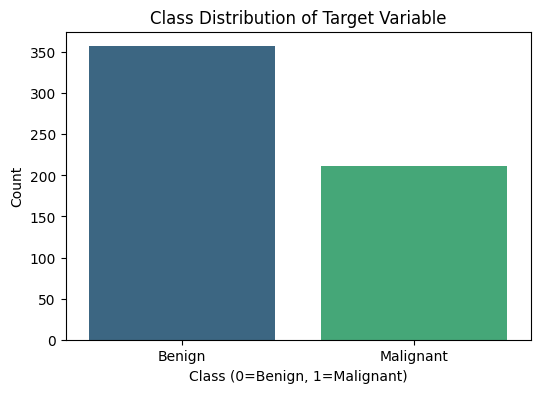

In [10]:
class_distribution = pd.Series(y).value_counts()
print('Class Distribution (0=Benign, 1=Malignant):\n', class_distribution)

plt.figure(figsize=(6, 4))
sns.barplot(x=class_distribution.index, y=class_distribution.values, palette='viridis')
plt.title('Class Distribution of Target Variable')
plt.xlabel('Class (0=Benign, 1=Malignant)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Benign', 'Malignant'])
plt.show()


### 2.4 Feature Distributions <font color="red">[2 marks]</font>

Pick 4-6 features and plot their distributions using histograms or boxplots. Look for skewness, outliers, and whether the two classes separate visually on any feature.


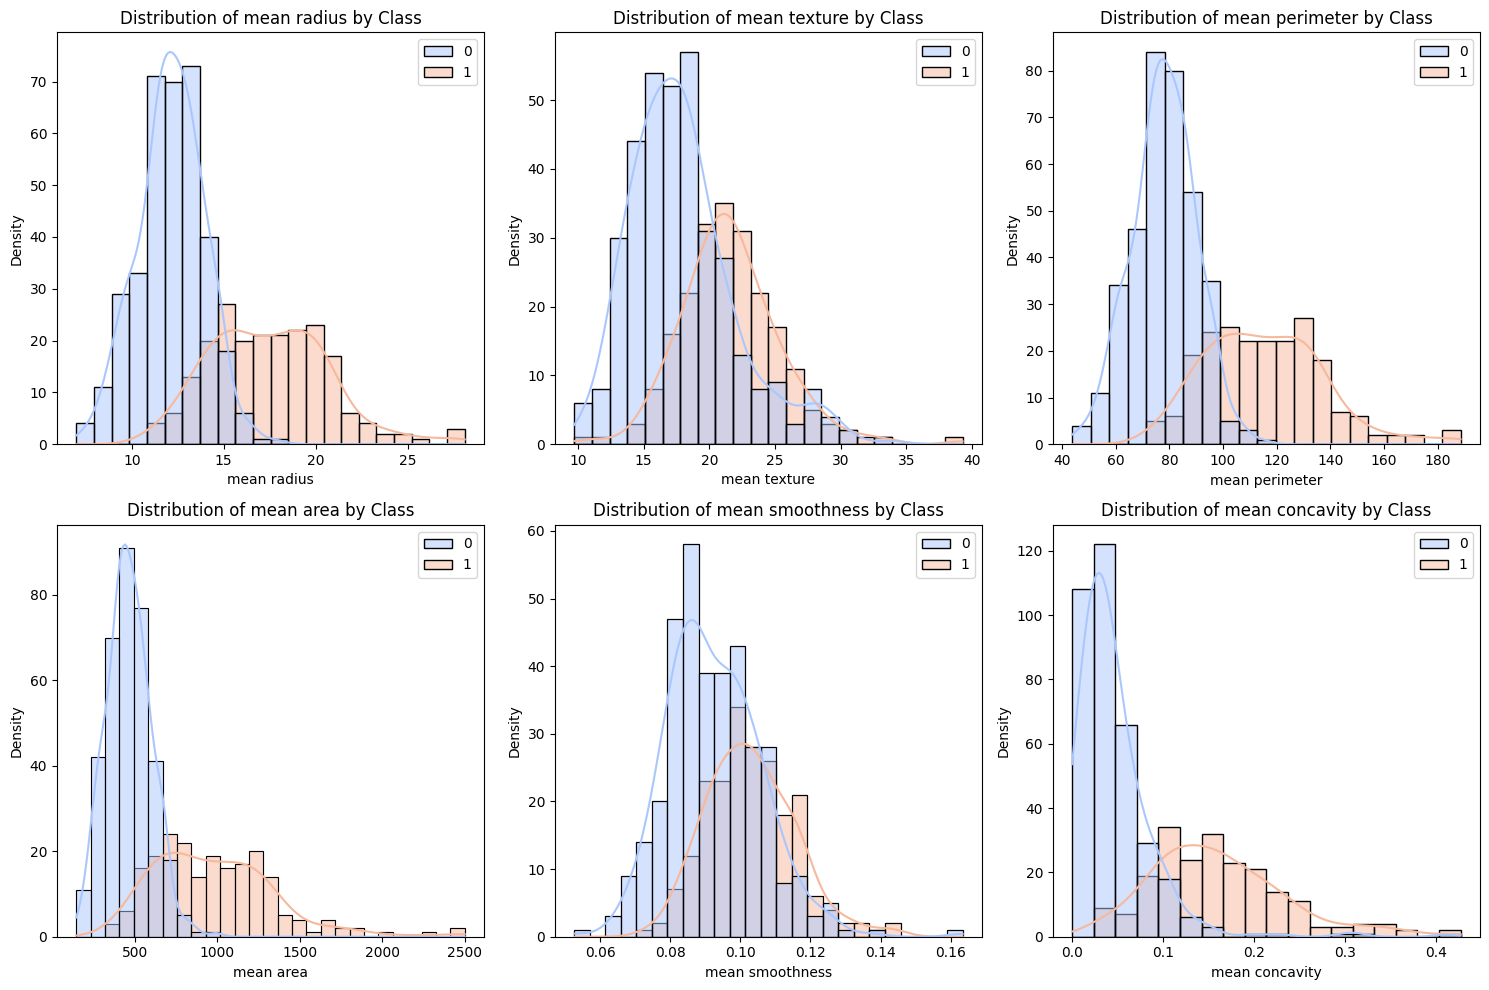

In [11]:
selected_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean concavity']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(selected_features):
    plt.subplot(2, 3, i + 1) # 2 rows, 3 columns
    sns.histplot(x=X[feature], hue=y, kde=True, palette='coolwarm')
    plt.title(f'Distribution of {feature} by Class')
    plt.xlabel(feature)
    plt.ylabel('Density')
plt.tight_layout()
plt.show()


### ✍️ Interpretation Checkpoint

**[Your Answer]:** Answer these questions in 2-3 sentences each:
1. Is the dataset balanced? How might imbalance affect model training?
2. Do the features have similar scales? What does this mean for models like KNN and SVM?


3. Why is recall a better primary metric than accuracy for this problem? 🇰

4. Why must we fit the scaler on training data only and not on the full dataset? What information from the test set would leak into training if we did?



*Write your answers here:*

1. ***your answer here***
: Data Set will be balance when it is closer to 50%. It is slightly inbalance or slight balance,

2. ***your answer here***
:  there are 569 row of 30 features,  some of feature like radius, area and smoothness are very far in values. Scaler requires to apply on KNN and SVM , It will give much importance to features with larger values. which can reduce prediction accuracy.

3. ***your answer here***
:: Recall = True Postive /(true postive + false Negative ) and this is about, patient life , Very high  accuracy requires. Recall will give high % of accuracy in this data sets .


4. ***your answer here***
:: It will imact distribution info of data and can change model accuracy.


## Stage 3: Data Preprocessing and Preparation

<font color="red">**[7 marks]**</font>


### 3.1 Missing Value Audit <font color="red">[1 mark]</font>

Confirm no missing values exist. If any do, handle them with median imputation.


In [12]:
# Missing value audit
### CODE HERE ###
if X.isnull().sum().sum() == 0 and pd.Series(y).isnull().sum() == 0:
    print('No missing values found in features (X) or target (y)')
else:
    print('Missing values found. Applying median imputation to features.')
    for col in X.columns:
        if X[col].isnull().any():
            median_val = X[col].median()
            X[col].fillna(median_val, inplace=True)
    print('Missing values in target (y) are not expected in this dataset, but if present, they should be handled based on context.')


No missing values found in features (X) or target (y)


### 3.2 Train-Test Split <font color="red">[2 marks]</font>

Split into 70% training and 30% test using **stratified sampling** to preserve the class ratio to mitigate any slight class imbalance. Use `random_state=42`.


In [13]:
# Stratified train-test split
### CODE HERE ###
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)


### 3.3 Feature Scaling <font color="red">[2 marks]</font>

Apply `StandardScaler`. **Fit the scaler on training data only**, then transform both train and test sets. If you fit on the full dataset, the scaler learns the mean and standard deviation of the test data, which inflates your results. That is data leakage.

> **Note:** Decision Trees split on thresholds and don't need scaling. But for consistency here, we scale for all models.


In [14]:
# Feature scaling: fit on train only, transform both
### CODE HERE ###
scaler = StandardScaler()
# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)
# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

### 3.4 Confirm Prepared Data <font color="red">[2 marks]</font>

Print shapes of your final training and test sets. Verify the class distribution is preserved in both.


In [15]:
# Confirm prepared data
### CODE HERE ###
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (398, 30)
X_test shape: (171, 30)
y_train shape: (398,)
y_test shape: (171,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Helper: Evaluation Function

You will evaluate many models. Rather than copy-pasting the same five lines every time, define a reusable function. Call it throughout Stages 4-6.


In [18]:
# Helper function. Use this to evaluate all models consistently.
### CODE HERE ###


## How GridSearchCV Works

If you haven't used `GridSearchCV` before, read this before moving on.

`GridSearchCV` automates hyperparameter tuning. You give it a set of parameter values to try, and it trains a model for every combination, scores each one using cross-validation, and tells you which combination won.

You can refer to the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

Here is the pattern you will repeat for every model below:

```python
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# 1. Define what parameter values to try
param_grid = {'C': [0.1, 1, 10]}

# 2. Set up GridSearchCV
grid = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=10000),
    param_grid=param_grid,
    scoring='recall',   # what metric to optimise
    cv=5,               # 5-fold cross-validation on training data
    n_jobs=-1            # use all CPU cores
)

# 3. Fit on training data
grid.fit(X_train_scaled, y_train)

# 4. Check results
print("Best parameters:", grid.best_params_)
print("Best CV recall:", grid.best_score_)
best_model = grid.best_estimator_

# 5. Predict on test set
y_pred = best_model.predict(X_test_scaled)
```

Every model below follows the same five steps. The only things that change are the estimator and the parameter grid.


## Stage 4: Model Training, Hyperparameter Tuning, and Evaluation

<font color="red">**[23 marks]**</font>

Train **four classifiers**, tune them, evaluate each one.

For each model:
1. Define the parameter grid
2. Run `GridSearchCV` with `scoring='recall'`, `cv=5`
3. Print the best parameters
4. Predict on the test set using the best estimator
5. Evaluate using `evaluate_model()`

> We use `scoring='recall'` because our goal is to catch malignant cases. Accuracy is misleading when classes are imbalanced.


### 4.1 Logistic Regression (Baseline) <font color="red">[5 marks]</font>

Logistic Regression with `class_weight='balanced'` to handle class imbalance.

**Hyperparameters to tune:**
- `C`: Regularisation strength. Try `[0.01, 0.1, 1, 10, 100]`
- Set `max_iter=10000` and `random_state=42`


In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Base model
log_regression = LogisticRegression(
    class_weight='balanced',
    max_iter=10000,
    random_state=42
)

# Hyperparameter grid
param_gri = {
    'C': [0.01, 0.1, 1, 10, 100]
}

# GridSearch with cross-validation
grid_search = GridSearchCV(
    estimator=log_regression,
    param_grid=param_gri,
    cv=5,
    scoring='recall',   # important for medical problems
    n_jobs=-1
)

# Fit model
grid_search.fit(X_train_scaled, y_train)



GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=10000, random_state=42),
             n_jobs=-1, param_grid={'C': [0.01, 0.1, 1, 10, 100]},
             scoring='recall')

In [20]:
# Evaluate LR on test set
### CODE HERE ###
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# Extract best model and print results
best_model = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)
print("Best CV recall:", grid_search.best_score_)

# Predictions on test set
y_pred = best_model.predict(X_test_scaled)

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Detailed Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Best parameters: {'C': 10}
Best CV recall: 0.9388505747126438
Accuracy : 0.9707602339181286
Recall   : 0.9375
Precision: 0.9836065573770492
F1 Score : 0.96

Confusion Matrix:
[[106   1]
 [  4  60]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       107
           1       0.98      0.94      0.96        64

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



### 4.2 K-Nearest Neighbours (KNN) <font color="red">[6 marks]</font>

[KNN](https://scikit-learn.org/stable/modules/neighbors.html) classifies a sample by majority vote of its nearest neighbours. Sensitive to feature scale, which is why we scaled the data.

**Hyperparameters to tune:**
- `n_neighbors`: Try `[3, 5, 7, 9, 11, 15]`
- `weights`: Try `['uniform', 'distance']`. Uniform gives equal votes. Distance gives closer neighbours more influence.

> Think about it: if malignant samples are sparse in a local neighbourhood, why might `weights='distance'` help?


In [21]:
# KNN with GridSearchCV
### CODE HERE ###

from sklearn.neighbors import KNeighborsClassifier

# Base model
knn = KNeighborsClassifier()

# Hyperparameter grid
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance']
}

# GridSearch with cross-validation
grid_search_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

# Fit model
grid_search_knn.fit(X_train_scaled, y_train)

# Extract best model
best_knn_model = grid_search_knn.best_estimator_
print("Best parameters for KNN:", grid_search_knn.best_params_)
print("Best CV recall for KNN:", grid_search_knn.best_score_)

Best parameters for KNN: {'n_neighbors': 7, 'weights': 'uniform'}
Best CV recall for KNN: 0.925287356321839


In [22]:
# Evaluate KNN on test set
### CODE HERE ###

# Predictions on test set
y_pred_knn = best_knn_model.predict(X_test_scaled)

# Metrics
print("KNN Accuracy :", accuracy_score(y_test, y_pred_knn))
print("KNN Recall   :", recall_score(y_test, y_pred_knn))
print("KNN Precision:", precision_score(y_test, y_pred_knn))
print("KNN F1 Score :", f1_score(y_test, y_pred_knn))

# Confusion Matrix
print("\nKNN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

# Detailed Classification Report
print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy : 0.9649122807017544
KNN Recall   : 0.90625
KNN Precision: 1.0
KNN F1 Score : 0.9508196721311475

KNN Confusion Matrix:
[[107   0]
 [  6  58]]

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       107
           1       1.00      0.91      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171



### 4.3 Decision Tree <font color="red">[6 marks]</font>

[Decision Trees](https://scikit-learn.org/stable/modules/tree.html) split features at thresholds. Without constraints, they memorise training data perfectly and fail on new data. That is overfitting.

**Hyperparameters to tune:**
- `max_depth`: Try `[3, 5, 7, 10, None]`. `None` means no limit.
- `min_samples_split`: Try `[2, 5, 10]`
- `min_samples_leaf`: Try `[1, 2, 4]`
- Use `class_weight='balanced'` and `random_state=42`


In [23]:
# Decision Tree with GridSearchCV
### CODE HERE ###
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Base model
dt = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

# Hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search
grid_search_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='recall',  # prioritize detecting malignant tumors
    n_jobs=-1
)

# Fit on training data
grid_search_dt.fit(X_train_scaled, y_train)

# Best model
best_dt = grid_search_dt.best_estimator_

print("Best Parameters:", grid_search_dt.best_params_)
print("Best CV Recall:", grid_search_dt.best_score_)


Best Parameters: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV Recall: 0.9319540229885057


In [24]:
# Evaluate Decision Tree on test set
### CODE HERE ###

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Predict on test set
y_pred_dt = best_dt.predict(X_test_scaled)

# Evaluation metrics
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


Accuracy : 0.9064327485380117
Recall   : 0.84375
Precision: 0.9
F1 Score : 0.8709677419354839

Confusion Matrix:
[[101   6]
 [ 10  54]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       107
           1       0.90      0.84      0.87        64

    accuracy                           0.91       171
   macro avg       0.90      0.89      0.90       171
weighted avg       0.91      0.91      0.91       171



### 4.4 Support Vector Machine (SVM) <font color="red">[6 marks]</font>

[SVMs](https://scikit-learn.org/stable/modules/svm.html) find the hyperplane that separates classes with the widest margin. With kernel functions, they can model non-linear boundaries.

**Hyperparameters to tune:**
- `C`: Try `[0.1, 1, 10]`
- `kernel`: Try `['linear', 'rbf']`. Linear for linearly separable data, RBF for non-linear.
- `gamma`: Try `['scale', 'auto']` (matters for RBF kernel)
- Use `class_weight='balanced'`, `random_state=42`, and `probability=True`

> **Why `probability=True`?** We need `predict_proba()` for threshold tuning in Stage 6.


In [25]:
# SVM with GridSearchCV
### CODE HERE ###
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Base model
svm = SVC(
    class_weight='balanced',
    probability=True,
    random_state=42
)

# Hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# GridSearchCV
grid_search_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

# Fit model
grid_search_svm.fit(X_train_scaled, y_train)

# Best model
best_svm = grid_search_svm.best_estimator_

print("Best Parameters:", grid_search_svm.best_params_)
print("Best CV Recall:", grid_search_svm.best_score_)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Recall: 0.9519540229885057


In [26]:
# Evaluate SVM on test set
### CODE HERE ###
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Predict on test set
y_pred_svm = best_svm.predict(X_test_scaled)

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))


Accuracy : 0.9824561403508771
Recall   : 0.96875
Precision: 0.9841269841269841
F1 Score : 0.9763779527559056

Confusion Matrix:
[[106   1]
 [  2  62]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       107
           1       0.98      0.97      0.98        64

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



## Stage 5: Model Comparison

<font color="red">**[9 marks]**</font>


### 5.1 Build a Comparison Table <font color="red">[3 marks]</font>

Create a DataFrame comparing all four models on the **test set**:
- Accuracy
- Recall (for malignant class)
- Precision (for malignant class)
- F1-Score (for malignant class)
- Number of False Negatives (from confusion matrix)

> **Hint:** A false negative is a malignant case predicted as benign. In the confusion matrix, it sits at position `[1][0]` when malignant = 1.


In [27]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

# Get predictions from each model
y_pred_lr = best_model.predict(X_test_scaled) # from Logistic Regression
y_pred_knn = best_knn_model.predict(X_test_scaled) # from KNN
y_pred_dt = best_dt.predict(X_test_scaled) # from Decision Tree
y_pred_svm = best_svm.predict(X_test_scaled) # from SVM

# Initialize lists to store metrics
model_names = ['Logistic Regression', 'KNN', 'Decision Tree', 'SVM']
accuracies = []
recalls = []
precisions = []
f1_scores = []
false_negatives = []

predictions = {
    'Logistic Regression': y_pred_lr,
    'KNN': y_pred_knn,
    'Decision Tree': y_pred_dt,
    'SVM': y_pred_svm
}

for name, y_p in predictions.items():
    accuracies.append(accuracy_score(y_test, y_p))
    recalls.append(recall_score(y_test, y_p))
    precisions.append(precision_score(y_test, y_p))
    f1_scores.append(f1_score(y_test, y_p))

    cm = confusion_matrix(y_test, y_p)
    false_negatives.append(cm[1][0]) # Malignant (1) predicted as Benign (0)

# Create DataFrame
comparison_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies,
    'Recall (Malignant)': recalls,
    'Precision (Malignant)': precisions,
    'F1-Score (Malignant)': f1_scores,
    'False Negatives': false_negatives
})

# Display the comparison table
display(comparison_df.set_index('Model'))

,Accuracy,Recall (Malignant),Precision (Malignant),F1-Score (Malignant),False Negatives
Model,,,,,
Logistic Regression,0.970760,0.93750,0.983607,0.960000,4
KNN,0.964912,0.90625,1.000000,0.950820,6
Decision Tree,0.906433,0.84375,0.900000,0.870968,10
SVM,0.982456,0.96875,0.984127,0.976378,2


### 5.2 Visualise Comparison <font color="red">[2 marks]</font>

Create a grouped bar chart comparing Recall and Precision across all four models.


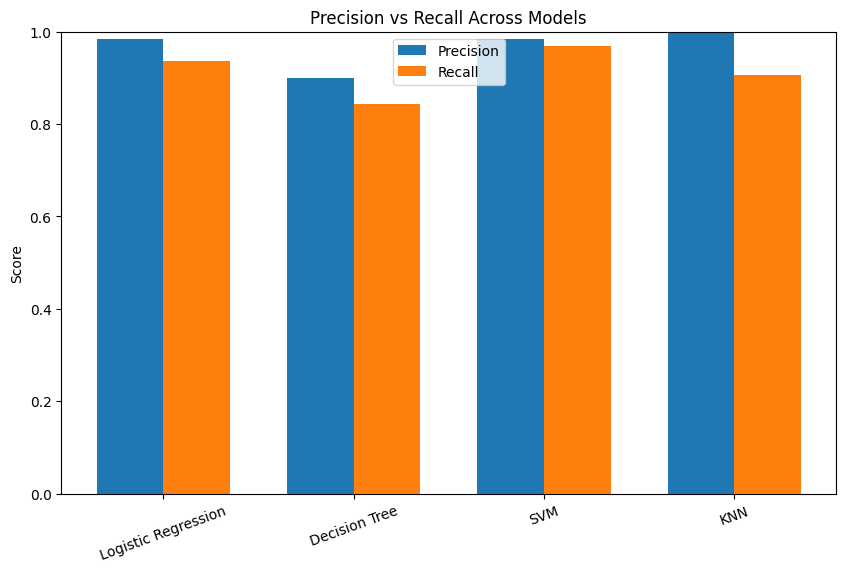

In [28]:
# Grouped bar chart: Recall and Precision
### CODE HERE ###
import numpy as np
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree", "SVM", "KNN"]

precision = [0.983607, 0.900000, 0.984127, 1.000000]
recall    = [0.93750, 0.84375	, 0.96875, 0.90625	]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(x - width/2, precision, width, label='Precision')
plt.bar(x + width/2, recall, width, label='Recall')

plt.xticks(x, models, rotation=20)
plt.ylabel("Score")
plt.title("Precision vs Recall Across Models")
plt.ylim(0, 1)
plt.legend()

plt.show()

### 5.3 Cross-Validation Stability <font color="red">[2 marks]</font>

For **all four models**, run 5-fold stratified [cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html) on the **training set** using `cross_val_score` with `scoring='recall'`. Print the mean and standard deviation of recall for each.

> **Why this matters:** High recall on one split means nothing if the model collapses on another. Stability tells you whether you can trust the number.

> **A caveat:** You are running `cross_val_score` on already-tuned estimators. This is a quick stability check, not a substitute for nested cross-validation. Good enough for a practice exercise.


In [31]:
# Cross-validation stability for all 4 models
### CODE HERE ###

from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": best_model,
    "Decision Tree": best_dt,
    "SVM": best_svm,
    "KNN": best_knn_model
}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring='recall'
    )

    print(f"{name}: {scores.mean():.3f} \u00b1 {scores.std():.3f}")

Logistic Regression: 0.952 ± 0.017
Decision Tree: 0.878 ± 0.072
SVM: 0.952 ± 0.028
KNN: 0.925 ± 0.051


### 5.4 Feature Importance <font color="red">[2 marks]</font>

Knowing *which features drive predictions* matters as much as the predictions themselves.

- Extract **feature importances** from your best Decision Tree (`.feature_importances_`) or **coefficients** from Logistic Regression (`.coef_[0]`)
- Plot the **top 10 most important features** as a horizontal bar chart


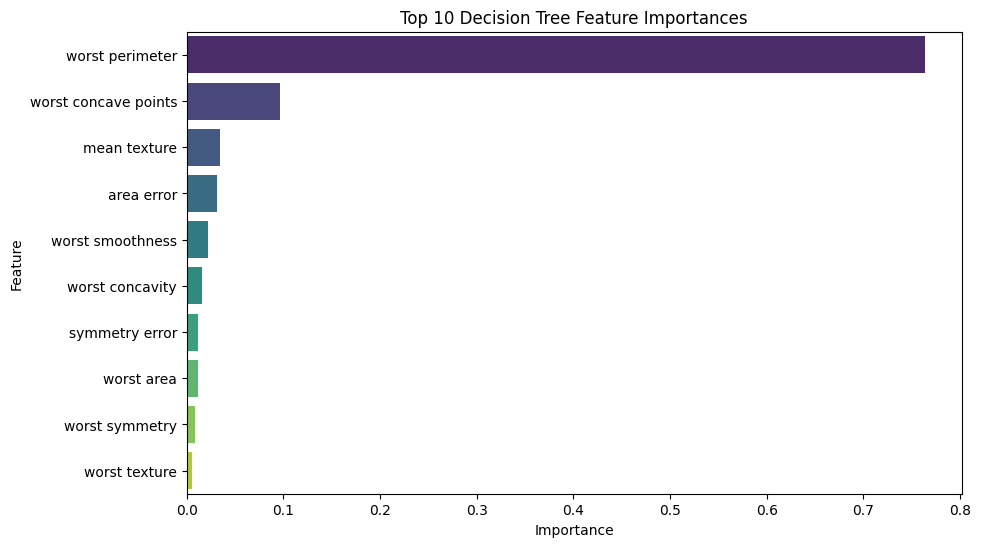

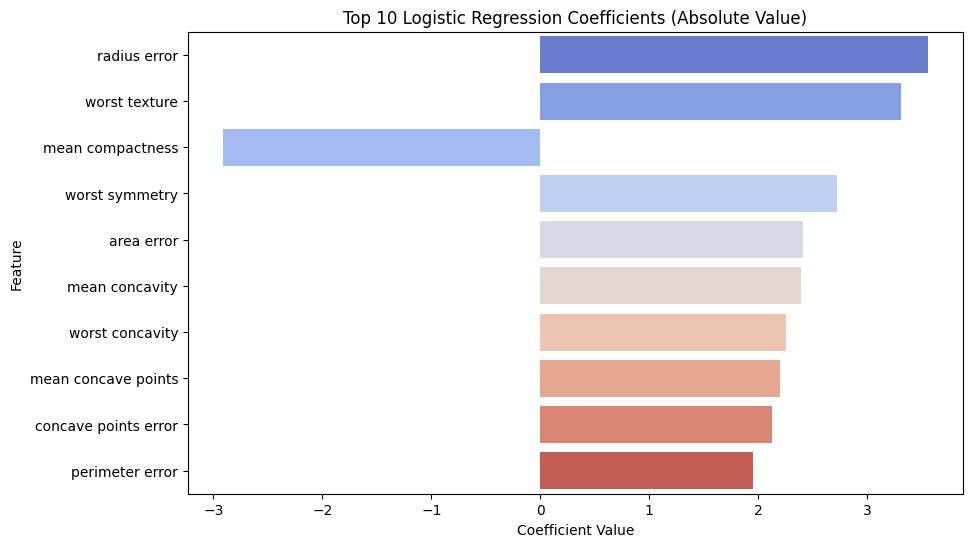

In [32]:
# Feature importance from Decision Tree
import pandas as pd
import numpy as np

importances = best_dt.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
).head(10)

# Plotting Decision Tree Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')
plt.title('Top 10 Decision Tree Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

coefficients = best_model.coef_[0]

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": coefficients
})

coef_df = coef_df.sort_values(by="coefficient", key=abs, ascending=False).head(10)

# Plotting Logistic Regression Coefficients
plt.figure(figsize=(10, 6))
sns.barplot(x='coefficient', y='feature', data=coef_df, palette='coolwarm')
plt.title('Top 10 Logistic Regression Coefficients (Absolute Value)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

## Stage 6: Final Model Selection

<font color="red">**[5 marks]**</font>


### 6.1 Threshold Tuning <font color="red">[2 marks]</font>

By default, classifiers use a probability threshold of 0.5 to assign classes. For medical diagnosis, we can lower this threshold to catch more malignant cases (higher recall) at the cost of more false positives (lower precision).

**Steps:**
1. Create a **stratified validation split from your training data** (70/30 from `X_train_scaled`). Do not touch the test set for this.
2. Retrain your best model on the inner training portion
3. Get predicted probabilities on the validation portion using `predict_proba()`
4. Plot the **precision-recall curve**
5. Find a threshold where recall ≥ 0.95

> **Why not tune on the test set?** If you use the test set to pick a threshold, your final evaluation on that same test set is no longer honest. The test set becomes a tuning surface, and your reported metrics are optimistic.


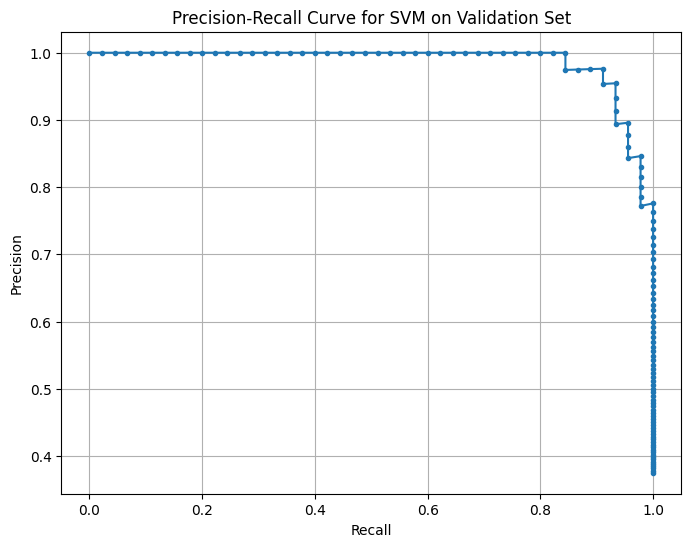

Optimal threshold for recall >= 0.95: 0.0004

Evaluation with optimal threshold on Validation Set:
Accuracy : 0.375
Recall   : 1.0
Precision: 0.375
F1 Score : 0.5454545454545454
Confusion Matrix:
 [[ 0 75]
 [ 0 45]]


In [33]:
# Threshold tuning on a VALIDATION split (not test set)
# Step 1: Create inner split from training data
X_train_inner, X_val, y_train_inner, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.3,
    stratify=y_train,
    random_state=42
)

# Step 2: Retrain best model (SVM) on inner training set
# Clone the best SVM model to ensure a fresh fit
best_svm_tuned = best_svm
best_svm_tuned.fit(X_train_inner, y_train_inner)

# Step 3: Get predicted probabilities on validation set
y_scores_svm = best_svm_tuned.predict_proba(X_val)[:, 1] # Probability of positive class (malignant)

# Step 4: Plot precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_val, y_scores_svm)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.')
plt.title('Precision-Recall Curve for SVM on Validation Set')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

# Step 5: Find threshold where recall >= 0.95
# Find the threshold that meets the recall requirement
threshold_to_meet_recall = 0.95
optimal_threshold = 0.5 # Default

for i in range(len(thresholds)):
    if recall[i] >= threshold_to_meet_recall:
        optimal_threshold = thresholds[i]
        break

print(f"Optimal threshold for recall >= {threshold_to_meet_recall:.2f}: {optimal_threshold:.4f}")

# Evaluate SVM with the new optimal threshold on the validation set
y_pred_tuned_val = (y_scores_svm >= optimal_threshold).astype(int)
print("\nEvaluation with optimal threshold on Validation Set:")
print("Accuracy :", accuracy_score(y_val, y_pred_tuned_val))
print("Recall   :", recall_score(y_val, y_pred_tuned_val))
print("Precision:", precision_score(y_val, y_pred_tuned_val))
print("F1 Score :", f1_score(y_val, y_pred_tuned_val))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_tuned_val))

### 6.2 Final Recommendation <font color="red">[3 marks]</font>

**[Your Answer]:** Answer the following. Cite specific numbers from your results.

1. Which model do you recommend and why? Reference its recall, false negative count, and cross-validation stability.
2. How many false negatives does it produce on the test set? Is this clinically acceptable?
3. What is one specific limitation of your analysis? (Not "more data." Be concrete, e.g., "the dataset has only 569 samples, which limits the reliability of cross-validation estimates.")


*Write your answers here:*

1. I recommend the SVM model because it achieved the best performance, with the highest recall (0.96875) and only 2 false negatives, which is critical for cancer detection. It also showed strong and stable cross-validation performance (0.952 ± 0.028).

2. Although this is acceptable for the recall target (≥ 0.95), in real medical settings we would prefer zero false negatives.

3. A limitation is that the validation set for threshold tuning was small (120 samples), which may reduce the reliability of the chosen threshold.

---
# PART 2: Multiclass Classification, Wine Dataset

## Context

The Wine dataset contains chemical analysis results of wines from the same region of Italy, grown from **three different cultivars** (grape varieties). The task: predict the cultivar (class 0, 1, or 2) based on 13 chemical attributes like alcohol content, malic acid, and flavanoids.

**Why Macro-F1 matters here:** No single wine class is more "dangerous" to misclassify. All three matter equally. Macro-averaged F1-score treats each class the same regardless of size.


## Stage 1: Data and Package Loading

<font color="red">**[2 marks]**</font>

Load the Wine dataset from `sklearn.datasets`. Convert to a DataFrame. Separate features and target. Import `MLPClassifier`.


In [ ]:
# Pre-imported for Part 2
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_wine

# Load wine dataset
wine_data = load_wine()
### CODE HERE ###


## Stage 2: Data Understanding

<font color="red">**[6 marks]**</font>


### 2.1 Basic Inspection <font color="red">[2 marks]</font>

Display the shape, first few rows, data types, and check for missing values.


In [ ]:
# Inspect the wine dataset
### CODE HERE ###


### 2.2 Class Distribution <font color="red">[2 marks]</font>

How many wines in each class? Visualise with a bar plot.


In [ ]:
# Wine class distribution
### CODE HERE ###


### 2.3 Feature Analysis <font color="red">[2 marks]</font>

Look at the feature ranges using `.describe()`. Some features range in the hundreds, others below 1. Then plot a **correlation heatmap** to see which features move together.


In [ ]:
# Summary statistics
### CODE HERE ###

# Correlation heatmap
### CODE HERE ###


### ✍️ Interpretation Checkpoint

**[Your Answer]:**
1. Are the three wine classes roughly balanced?
2. Looking at the feature ranges, do some features dominate others in scale? What does this imply for models like KNN and SVM?


*Write your answers here:*

1. ***your answer here***

2. ***your answer here***


## Stage 3: Data Preprocessing

<font color="red">**[4 marks]**</font>


### 3.1 Split and Scale <font color="red">[2 marks]</font>

Stratified train-test split (70-30, `random_state=42`), then `StandardScaler` fit on training data only. Stratification for handling any slight class imbalance in the data.

> **Reminder:** Decision Trees don't need scaling, but KNN, SVM, MLP, and Logistic Regression all do. We scale for all models here.


In [ ]:
# Stratified train-test split
### CODE HERE ###


In [ ]:
# Scale features: fit on train, transform both
### CODE HERE ###


### 3.2 Verify Preparation <font color="red">[2 marks]</font>

Print shapes and class distributions for both splits.


In [ ]:
# Verify preparation
### CODE HERE ###


## Stage 4: Model Training and Hyperparameter Tuning

<font color="red">**[20 marks]**</font>

Train **five classifiers** on the wine dataset. Use `GridSearchCV` with `scoring='f1_macro'` and `cv=5` for each. Use the `evaluate_model()` helper from Part 1.

> **Key difference from Part 1:** We optimise for `f1_macro` instead of `recall`, because all classes matter equally.


### 4.1 Logistic Regression <font color="red">[3 marks]</font>

**Hyperparameters:**
- `C`: `[0.01, 0.1, 1, 10]`
- `max_iter`: `10000`
- `random_state`: `42`


In [ ]:
# Logistic Regression for Wine
### CODE HERE ###


### 4.2 K-Nearest Neighbours <font color="red">[3 marks]</font>

**Hyperparameters:**
- `n_neighbors`: `[3, 5, 7, 9, 11]`
- `weights`: `['uniform', 'distance']`


In [ ]:
# KNN for Wine
### CODE HERE ###


### 4.3 Decision Tree <font color="red">[3 marks]</font>

**Hyperparameters:**
- `max_depth`: `[3, 5, 7, 10, None]`
- `min_samples_split`: `[2, 5, 10]`
- `min_samples_leaf`: `[1, 2, 4]`
- `random_state`: `42`


In [ ]:
# Decision Tree for Wine
### CODE HERE ###


### 4.4 Support Vector Machine <font color="red">[3 marks]</font>

**Hyperparameters:**
- `C`: `[0.1, 1, 10]`
- `kernel`: `['linear', 'rbf']`
- `gamma`: `['scale', 'auto']`
- `random_state`: `42`


In [ ]:
# SVM for Wine
### CODE HERE ###


### 4.5 Multi-Layer Perceptron (MLP) <font color="red">[8 marks]</font>

The MLP is a neural network. Unlike the previous models, you control the **architecture**: how many layers, how many neurons per layer.

**Hyperparameters to tune:**
- `hidden_layer_sizes`: Try `[(50,), (100,), (50, 50), (100, 50)]`. Each tuple defines layer widths.
- `activation`: Try `['relu', 'tanh']`. The non-linear function at each neuron.
- `alpha`: Try `[0.0001, 0.001, 0.01]`. L2 regularisation to prevent overfitting.
- Set `max_iter=2000`, `random_state=42`, and `early_stopping=True`

> **What is early stopping?** It monitors validation performance during training and stops when performance plateaus. Without it, the network keeps training until it memorises the data.


In [ ]:
# MLP for Wine
### CODE HERE ###


In [ ]:
# Evaluate MLP on test set
### CODE HERE ###


### ✍️ MLP Interpretation

**[Your Answer]:**
1. What architecture (hidden layer sizes) performed best? Why do you think that configuration won?
2. Did the MLP outperform the classical models? By how much in macro-F1?
3. What role does `alpha` (regularisation) play? What happens if it is set too high? Too low?


*Write your answers here:*

1. ***your answer here***

2. ***your answer here***

3. ***your answer here***


## Stage 5: Model Comparison

<font color="red">**[8 marks]**</font>


### 5.1 Comparison Table <font color="red">[3 marks]</font>

Create a DataFrame comparing all five models on the **test set**:
- Accuracy
- Macro-Precision
- Macro-Recall
- Macro-F1-Score


In [ ]:
# Comparison table for all 5 wine models
### CODE HERE ###


### 5.2 Visualise Comparison <font color="red">[2 marks]</font>

Bar chart comparing Macro-F1 scores across all five models.


In [ ]:
# Macro-F1 bar chart
### CODE HERE ###


### 5.3 Cross-Validation Stability <font color="red">[3 marks]</font>

For **all five models**, run 5-fold cross-validation with `scoring='f1_macro'` on the training set. Print the mean and standard deviation for each.


In [ ]:
# Cross-validation stability for all 5 wine models
### CODE HERE ###


### ✍️ Classical vs Neural Comparison

**[Your Answer]:**
1. Which classical model performed best on macro-F1? Why might that be?
2. Did the MLP beat the classical models by a clear margin, or was the gap small?
3. When would you choose a simpler model like Logistic Regression over the MLP, even if the MLP scores slightly higher?


*Write your answers here:*

1. ***your answer here***

2. ***your answer here***

3. ***your answer here***


## Stage 6: Final Recommendation

<font color="red">**[5 marks]**</font>


### 6.1 Final Model Selection <font color="red">[3 marks]</font>

**[Your Answer]:**
1. Which model do you recommend as the best **classical** model for the wine dataset? Cite its macro-F1 score.
2. Which model do you recommend as the best **overall** model? Consider performance vs interpretability.
3. If a winemaker wanted to understand *why* a wine was classified as a certain cultivar, which model would you recommend and why?


*Write your answers here:*

1. ***your answer here***

2. ***your answer here***

3. ***your answer here***


### 6.2 Underfitting vs Overfitting Study <font color="red">[2 marks]</font>

Train three Decision Tree variants on the wine dataset:
1. `max_depth=1` with `random_state=42` (too simple, underfits)
2. `max_depth=None` with `random_state=42` (no constraints, overfits)
3. Your best tuned tree from Stage 4

For each, print the **training accuracy** and **test accuracy**. Look at the gap.


In [ ]:
# Overfitting study: 3 Decision Tree variants
### CODE HERE ###


### ✍️ Underfitting vs Overfitting

**[Your Answer]:**
1. Which variant underfits? How can you tell from the train/test accuracy?
2. Which variant overfits? What is the gap between train and test accuracy?
3. How does the tuned model sit between these two extremes?


*Write your answers here:*

1. ***your answer here***

2. ***your answer here***

3. ***your answer here***


---
## Indicative Mark Summary

> **Reminder:** These marks are for self-assessment only. They do not count towards your final grade.

| Section | Topic | Marks |
|---------|-------|-------|
| **Part 1** | | **55** |
| Stage 1 | Data Loading | 3 |
| Stage 2 | Data Understanding + Interpretation | 8 |
| Stage 3 | Preprocessing | 7 |
| Helper + Tutorial | Evaluation Function, GridSearchCV Walkthrough | 0 |
| Stage 4 | Model Training and Tuning (4 models) | 23 |
| Stage 5 | Model Comparison + Feature Importance | 9 |
| Stage 6 | Final Model Selection | 5 |
| **Part 2** | | **45** |
| Stage 1 | Data Loading | 2 |
| Stage 2 | Data Understanding + Interpretation | 6 |
| Stage 3 | Preprocessing | 4 |
| Stage 4 | Model Training and Tuning (5 models, incl. MLP) | 20 |
| Stage 5 | Model Comparison | 8 |
| Stage 6 | Final Recommendation | 5 |
| | **Total** | **100** |

---
*End of Practice Assignment*
